In [1]:
#importation des modules
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split   
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
from torch.utils.data import WeightedRandomSampler
from collections import Counter


ModuleNotFoundError: No module named 'torch'

In [ ]:
#attention, j'ai inversé les conventions pour les classes : 0=cancer, 1=normal

In [ ]:
#restructuration des données : on garde que le point de vue MLO pour chaque sein
import os
import shutil

def restructure_normale_data():
    source="/home/onyxia/s3/hlegarzic/stat_app/MINI-DDSM-Complete-JPEG-8/Normal"
    destination="./MINI-DDSM-Complete-JPEG-82/normal"
    for filename in os.listdir(source):
        source_filename= source + "\\" + filename
        chemin_MLO_right=os.path.join(source_filename,"A_"+filename+"_1.RIGHT_MLO.jpg")
        chemin_MLO_left=os.path.join(source_filename,"A_"+filename+"_1.LEFT_MLO.jpg")
        if os.path.exists(chemin_MLO_right):
            shutil.copy2(chemin_MLO_right,destination)
        if os.path.exists(chemin_MLO_left):
            shutil.copy2(chemin_MLO_left,destination)
    print("Restructuration terminée")


def restructuration_cancer():
    source="/home/onyxia/s3/hlegarzic/stat_app/MINI-DDSM-Complete-JPEG-8/Cancer"
    destination1="./MINI-DDSM-Complete-JPEG-82/cancer_benign"
    destination2="./MINI-DDSM-Complete-JPEG-82/normal"
    c=0
    for filename in os.listdir(source):
        #identification de la lettre correcte
        ok=False
        i=0
        l=["A_","B_","C_","D_"]
        source_filename= source + "\\" + filename
        while ok == False:
            chemin_MLO_right=os.path.join(source_filename,l[i]+filename+"_1.RIGHT_MLO.jpg")
            if os.path.exists(chemin_MLO_right):
                ok = True
            else:
                i+=1
        if i==4:
            print("erreur1 avec le fichier "+filename)

        #identification cancer gauche ou droit
        orientation=None
        if os.path.exists(os.path.join(source_filename,l[i]+filename+"_1.RIGHT_MLO.OVERLAY")):
             orientation="RIGHT"
        elif os.path.exists(os.path.join(source_filename,l[i]+filename+"_1.LEFT_MLO.OVERLAY")):
            orientation="LEFT"
        else:
             print("cancer uniquement visible sur le point de vue CC "+filename)
        #copie des images
        if orientation=="RIGHT":
            shutil.copy2(chemin_MLO_right,destination1)
            shutil.copy2(os.path.join(source_filename,l[i]+filename+"_1.LEFT_MLO.jpg"),destination2)
        if orientation=="LEFT":
            shutil.copy2(os.path.join(source_filename,l[i]+filename+"_1.LEFT_MLO.jpg"),destination1)
            shutil.copy2(chemin_MLO_right,destination2)


def restructuration_benign():
    source="/home/onyxia/s3/hlegarzic/stat_app/MINI-DDSM-Complete-JPEG-8/Benign"
    destination1="./MINI-DDSM-Complete-JPEG-82/cancer_benign"
    destination2="./MINI-DDSM-Complete-JPEG-82/normal"
    for filename in os.listdir(source):
        #identification de la lettre correcte
        ok=False
        i=0
        l=["A_","B_","C_","D_"]
        source_filename= source + "\\" + filename
        while ok == False:
            chemin_MLO_right=os.path.join(source_filename,l[i]+filename+"_1.RIGHT_MLO.jpg")
            if os.path.exists(chemin_MLO_right):
                ok = True
            else:
                i+=1
        if i==4:
            print("erreur1 avec le fichier "+filename)

        #identification cancer gauche ou droit
        orientation=None
        if os.path.exists(os.path.join(source_filename,l[i]+filename+"_1.RIGHT_MLO.OVERLAY")):
             orientation="RIGHT"
        elif os.path.exists(os.path.join(source_filename,l[i]+filename+"_1.LEFT_MLO.OVERLAY")):
            orientation="LEFT"
        else:
             print("cancer uniquement visible sur le point de vue CC "+filename)
        #copie des images
        if orientation=="RIGHT":
            shutil.copy2(chemin_MLO_right,destination1)
            shutil.copy2(os.path.join(source_filename,l[i]+filename+"_1.LEFT_MLO.jpg"),destination2)
        if orientation=="LEFT":
            shutil.copy2(os.path.join(source_filename,l[i]+filename+"_1.LEFT_MLO.jpg"),destination1)
            shutil.copy2(chemin_MLO_right,destination2)


print("Restructuration terminée")

#restructure_normale_data()
#restructuration_cancer()
#restructuration_benign()


Restructuration terminée
cancer uniquement visible sur le point de vue CC 0367
cancer uniquement visible sur le point de vue CC 1714
cancer uniquement visible sur le point de vue CC 1786
cancer uniquement visible sur le point de vue CC 1862
cancer uniquement visible sur le point de vue CC 1869
cancer uniquement visible sur le point de vue CC 3149
cancer uniquement visible sur le point de vue CC 3155


In [22]:
#génération des données équilibrées

#standardisation de la transformation des images pour coller au modèle restnet18
transform = transforms.Compose([
    transforms.Resize((700,700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
data_set=ImageFolder(root=".\\MINI-DDSM-Complete-JPEG-82", transform=transform)
label=np.array(data_set.targets)
print(label)

numero_random=42
train_size=0.7
val_size=0.15
test_size=0.15

sss1=StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=numero_random)
for train_val_index, test_index in sss1.split(np.zeros(len(label)), label):
    train_val_indices=train_val_index
    test_indices=test_index

train_val_labels=label[train_val_indices]

new_val_size=val_size/(train_size+val_size)
ss2=StratifiedShuffleSplit(n_splits=1, test_size=new_val_size, random_state=numero_random)
for train_index, val_index in ss2.split(np.zeros(len(train_val_labels)), train_val_labels):
    train_indices=train_val_indices[train_index]
    val_indices=train_val_indices[val_index]

train_labels=label[train_indices]
class_counts=Counter(train_labels)
print(f"Comptes des classes dans le jeu d'entraînement: {class_counts} \n")
num_labels=len(train_labels)
weight_for_class={cl : num_labels/count for cl, count in class_counts.items()}
sample_weights=[weight_for_class[l] for l in train_labels]
sample_weights_tensor=torch.DoubleTensor(sample_weights)
print(f"poids calculés par classe :{weight_for_class} \n")

sampler = WeightedRandomSampler(weights=sample_weights_tensor, num_samples=len(sample_weights_tensor), replacement=True)
distribution_sampler=Counter(train_labels[list(sampler)])
print(f"Distribution des classes dans le sampler : {distribution_sampler} \n")
train_set=Subset(data_set, train_indices)
val_set=Subset(data_set, val_indices)
test_set=Subset(data_set, test_indices)

print(f"Train set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")

bs=6  
train_loader = DataLoader(train_set, batch_size=bs, sampler=sampler, shuffle=False)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False)


[0 0 0 ... 1 1 1]
Comptes des classes dans le jeu d'entraînement: Counter({np.int64(1): 1633, np.int64(0): 932}) 

poids calculés par classe :{np.int64(0): 2.7521459227467813, np.int64(1): 1.5707287201469688} 

Distribution des classes dans le sampler : Counter({np.int64(1): 1310, np.int64(0): 1255}) 

Train set size: 2565
Validation set size: 550
Test set size: 550


In [ ]:
#entraînement du modèle
#importation du modèle (ResNet18 pré-entraîné ou non)
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
#model=models.resnet18(weights=None)
#model.fc = torch.nn.Linear(512,2)
#model.load_state_dict(torch.load("best_resnet18_model_ordonnanceur.pth"))


#définition du nombre de classes, ici 3 : cancer, bénin, normal
num_class=2
model.fc = torch.nn.Linear(model.fc.in_features, num_class)

#choix fonction de perte et de l'optimiseur
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) 

#définition de l'appareil d'entraînement (GPU si dispo)
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)


num_epochs=0

#ordonnanceur / scheduler
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3, threshold=0.0001)

def train_model(model, train_loader, val_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss=criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss= running_loss / len(train_loader.dataset)
    return(epoch_loss)

def validate_model(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    corrects = 0.0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _,preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss / len(val_loader.dataset)
        epoch_acc = corrects.double() / len(val_loader.dataset)
        return(epoch_loss, epoch_acc)
    
best_acc=0.0

def entrain_and_validate():
    global best_acc
    patience_limite=5
    patience_compteur=0
    for epoch in range(num_epochs):
        print(patience_compteur)
        print(f"\n--- Époque {epoch+1}/{num_epochs} ---")

        train_loss=train_model(model, train_loader, val_loader, criterion, optimizer)
        print(f"Loss d'entraînement: {train_loss:.4f}")

        val_loss, val_acc=validate_model(model, val_loader, criterion, device)
        print(f"Loss de validation: {val_loss:.4f} | Accuracy de validation: {val_acc:.4f}")

        scheduler.step(val_acc)

        current_lr=optimizer.param_groups[0]['lr']
        print(f"Taux d'apprentissage actuel: {current_lr}")

        if best_acc < val_acc:
            best_acc=val_acc
            torch.save(model.state_dict(), "best_resnet18_model_ordonnanceur.pth")
            patience_compteur=0
            print("Modèle sauvegardé.")
        else:
            patience_compteur+=1
            if patience_compteur >= patience_limite:
                print("Arrêt anticipé déclenché.")
                break

    print("\nEntraînement terminé.")

entrain_and_validate()


0

--- Époque 1/50 ---


Training: 100%|██████████| 428/428 [06:32<00:00,  1.09it/s]


Loss d'entraînement: 0.6019


Validating: 100%|██████████| 92/92 [01:00<00:00,  1.51it/s]


Loss de validation: 0.6147 | Accuracy de validation: 0.5927
Taux d'apprentissage actuel: 0.0001
Modèle sauvegardé.
0

--- Époque 2/50 ---


...

Loss de validation: 0.8820 | Accuracy de validation: 0.6691
Taux d'apprentissage actuel: 1.0000000000000002e-06
6

--- Époque 19/50 ---


Training: 100%|██████████| 428/428 [06:27<00:00,  1.10it/s]


Loss d'entraînement: 0.0337


Validating: 100%|██████████| 92/92 [00:51<00:00,  1.80it/s]

Loss de validation: 0.9113 | Accuracy de validation: 0.6655
Taux d'apprentissage actuel: 1.0000000000000002e-06
Arrêt anticipé déclenché.

Entraînement terminé.


In [24]:
#extraction des résultats sur test set ou sur val set
import torch.nn.functional as F
model.load_state_dict(torch.load("best_resnet18_model_ordonnanceur.pth"))


choose_data=test_loader  #choisir entre "test" ou "val"
model.eval()

all_predictions = []
all_labels= []
all_probabilities = []

with torch.no_grad():
    for inputs, labels in tqdm(choose_data):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        probabilities = F.softmax(outputs, dim=1)
        _,preds=torch.max(outputs,1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        #pour le calcul de l'AUC, on peut aussi stocker les probabilités
        positive_class_probs = probabilities[:, 0].cpu().numpy()
        all_probabilities.extend(positive_class_probs)
        # Traitez les probabilités comme nécessaire

predictions_np=np.array(all_predictions)
labels_np=np.array(all_labels)
probabilities_np=np.array(all_probabilities)


accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')


100%|██████████| 92/92 [01:05<00:00,  1.41it/s]

Test_Accuracy : 69.0909%


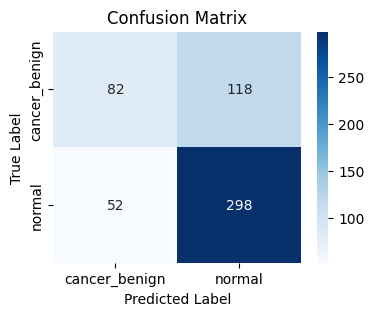

In [ ]:
#matrice de confusion

class_names = ['cancer_benign', 'normal']
cm = confusion_matrix(labels_np, predictions_np)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')   
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



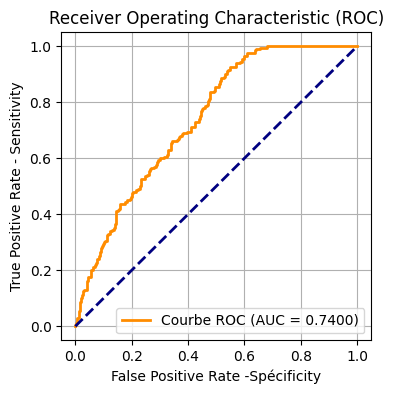

In [ ]:
#calcul de l'AUC et de la courbe ROC
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(labels_np, probabilities_np, pos_label=0)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate -Spécificity')
plt.ylabel('True Positive Rate - Sensitivity')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



In [28]:

report = classification_report(labels_np, predictions_np, target_names=class_names)
print("rapport de classification : ")
print(report)

rapport de classification : 
               precision    recall  f1-score   support

cancer_benign       0.61      0.41      0.49       200
       normal       0.72      0.85      0.78       350

     accuracy                           0.69       550
    macro avg       0.66      0.63      0.63       550
 weighted avg       0.68      0.69      0.67       550



In [ ]:
#visualisations d'exemples spécifiques
misclassified_indices = np.where(predictions_np != labels_np)[0]
#revenir en arrière pour afficher des images mal classées si besoin, à voir plus en détail...